In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print("train:", train.shape, "| test:", test.shape)
train.head()

train: (3200, 43) | test: (800, 42)


,id,nilai_minggu_01,nilai_minggu_02,nilai_minggu_03,nilai_minggu_04,nilai_minggu_05,nilai_minggu_06,nilai_minggu_07,nilai_minggu_08,nilai_minggu_09,nilai_minggu_10,nilai_minggu_11,nilai_minggu_12,skor_motivasi,skor_kedisiplinan,aktivitas_hari_01,aktivitas_hari_02,aktivitas_hari_03,aktivitas_hari_04,aktivitas_hari_05,aktivitas_hari_06,aktivitas_hari_07,aktivitas_hari_08,aktivitas_hari_09,aktivitas_hari_10,aktivitas_hari_11,aktivitas_hari_12,aktivitas_hari_13,aktivitas_hari_14,aktivitas_hari_15,aktivitas_hari_16,tugas_selesai,tugas_diberikan,kelas,urutan_ujian,skor_tryout,jarak_rumah_km,skor_ekstrakurikuler,indeks_kehadiran,skor_literasi,jumlah_saudara,skor_minat_belajar,target
0,0,2.6,6.4,3.6,1.0,4.4,8.5,-4.0,-0.1,-4.7,1.0,-4.7,-5.1,-0.53,-0.33,64.3,42.7,42.4,65.4,77.6,61.2,36.8,34.4,51.8,89.6,55.2,44.7,42.0,46.7,69.2,46.9,8,9,114,0.0817,72.3,0.46,0.00,-0.38,-0.24,-0.70,-0.62,3
1,1,-0.3,5.7,1.7,1.3,6.1,5.8,-0.1,-3.8,-3.1,-3.1,-1.0,1.0,-2.24,1.82,27.8,51.6,53.6,56.4,40.7,68.0,66.4,30.5,51.8,74.3,61.4,41.6,38.7,72.0,31.7,32.6,46,85,301,0.3388,41.4,-1.29,0.51,0.86,-0.70,-1.04,2.15,1
2,2,-4.8,-0.8,-3.5,-6.3,-3.7,-1.5,10.7,8.7,5.8,5.2,7.2,9.9,-1.18,-1.34,33.9,50.4,50.0,36.4,73.0,66.4,36.6,62.2,60.5,35.9,49.0,63.3,43.7,47.2,53.5,44.9,23,75,28,0.0517,73.2,-0.03,-0.33,0.14,0.80,0.26,-0.57,3
3,4,4.7,1.1,2.1,0.2,1.9,1.4,-0.5,-0.3,0.5,-1.4,-1.2,3.6,-0.60,0.69,51.0,48.0,36.5,31.8,53.0,60.7,76.7,65.1,51.1,39.0,36.4,41.9,49.1,56.2,70.6,64.5,95,110,580,0.0310,59.1,-0.20,0.24,1.68,-0.44,1.32,-0.64,1
4,5,13.3,3.5,3.4,4.1,6.2,8.7,-5.0,-6.1,-5.2,-8.2,-7.1,-6.6,-1.19,-0.67,59.2,43.0,43.6,64.6,57.7,42.2,57.7,57.7,47.9,37.2,62.3,77.4,36.5,42.2,58.5,52.8,24,32,127,0.5829,60.7,1.06,0.49,0.42,-1.36,-0.45,-1.92,3


In [60]:
train.info() 

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3200 non-null   int64  
 1   nilai_minggu_01       3200 non-null   float64
 2   nilai_minggu_02       3200 non-null   float64
 3   nilai_minggu_03       3200 non-null   float64
 4   nilai_minggu_04       3200 non-null   float64
 5   nilai_minggu_05       3200 non-null   float64
 6   nilai_minggu_06       3200 non-null   float64
 7   nilai_minggu_07       3200 non-null   float64
 8   nilai_minggu_08       3200 non-null   float64
 9   nilai_minggu_09       3200 non-null   float64
 10  nilai_minggu_10       3200 non-null   float64
 11  nilai_minggu_11       3200 non-null   float64
 12  nilai_minggu_12       3200 non-null   float64
 13  skor_motivasi         3200 non-null   float64
 14  skor_kedisiplinan     3200 non-null   float64
 15  aktivitas_hari_01     3200 non-n

In [61]:
print("Total missing values:", int(train.isna().sum().sum()))

train.describe().T.head(20) 

Total missing values: 0


,count,mean,std,min,25%,50%,75%,max
id,3200.0,2011.313437,1163.716874,0.00,997.750,2030.50,3013.250,3999.00
nilai_minggu_01,3200.0,0.034469,4.603547,-12.80,-3.500,-0.00,3.500,13.90
nilai_minggu_02,3200.0,0.018188,4.538317,-13.70,-3.300,0.00,3.400,13.20
nilai_minggu_03,3200.0,-0.021969,4.630500,-12.90,-3.400,-0.10,3.400,12.80
nilai_minggu_04,3200.0,0.013188,4.656880,-13.70,-3.525,0.00,3.600,14.50
nilai_minggu_05,3200.0,-0.046656,4.579261,-13.50,-3.400,-0.10,3.300,13.40
nilai_minggu_06,3200.0,-0.023094,4.595992,-13.90,-3.400,-0.15,3.300,13.20
nilai_minggu_07,3200.0,0.018969,4.566149,-15.20,-3.325,0.00,3.300,13.60
nilai_minggu_08,3200.0,0.072031,4.664008,-13.10,-3.500,0.10,3.600,14.70
nilai_minggu_09,3200.0,-0.062969,4.564136,-12.90,-3.500,-0.05,3.400,11.80


{0: 813, 1: 796, 2: 784, 3: 807}


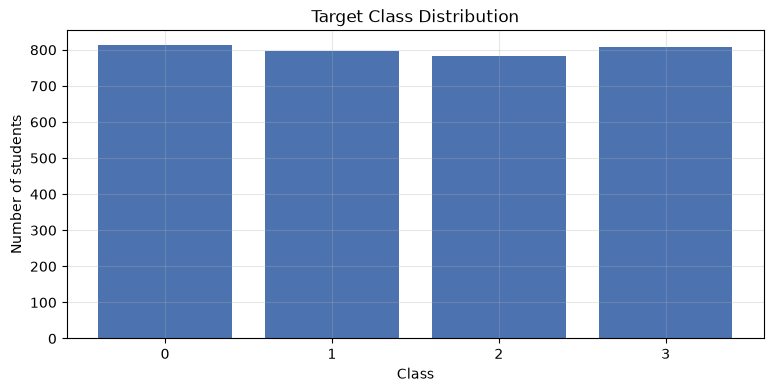

In [62]:
counts = train["target"].value_counts().sort_index()

print(counts.to_dict())


fig, ax = plt.subplots()

ax.bar(counts.index.astype(str), counts.values, color="#4C72B0")

ax.set_title("Target Class Distribution")

ax.set_xlabel("Class"); ax.set_ylabel("Number of students")

plt.show() 

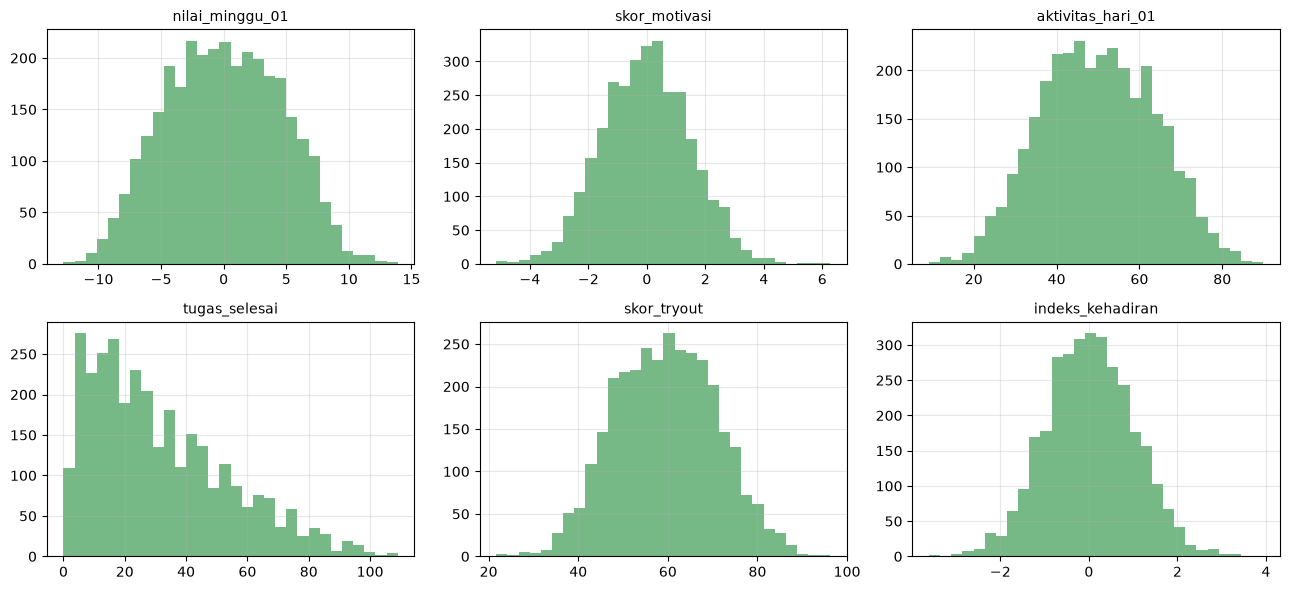

In [63]:
sample_cols = ["nilai_minggu_01", "skor_motivasi", "aktivitas_hari_01",
   "tugas_selesai", "skor_tryout", "indeks_kehadiran"]


fig, axes = plt.subplots(2, 3, figsize=(13, 6))

for col, ax in zip(sample_cols, axes.ravel()):

    ax.hist(train[col], bins=30, color="#55A868", alpha=0.8)

    ax.set_title(col, fontsize=10)

plt.tight_layout(); plt.show() 

Max |correlation|   : 0.215
Median |correlation|: 0.011


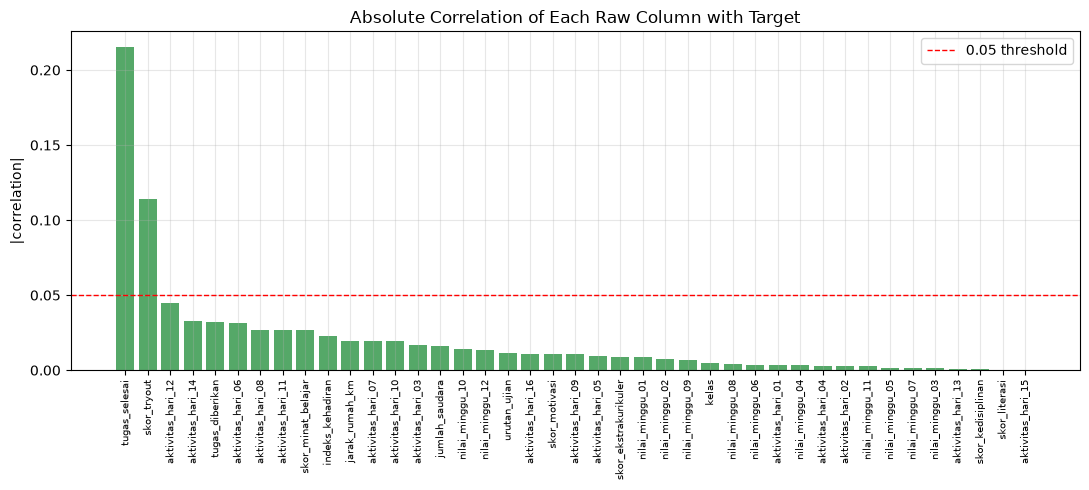

In [64]:
feat_cols = [col for col in train.columns if col not in ("id", "target")]


corr = (train[feat_cols]

        .apply(lambda col: np.corrcoef(col, train["target"])[0, 1])

        .abs()

        .sort_values(ascending=False))


print("Max |correlation|   :", round(corr.max(), 3))

print("Median |correlation|:", round(corr.median(), 3))


fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(range(len(corr)), corr.values, color="#55A868")

ax.axhline(0.05, color="red", ls="--", lw=1, label="0.05 threshold")

ax.set_xticks(range(len(corr)))

ax.set_xticklabels(corr.index, rotation=90, fontsize=7)

ax.set_title("Absolute Correlation of Each Raw Column with Target")

ax.set_ylabel("|correlation|"); ax.legend()

plt.tight_layout(); plt.show() 

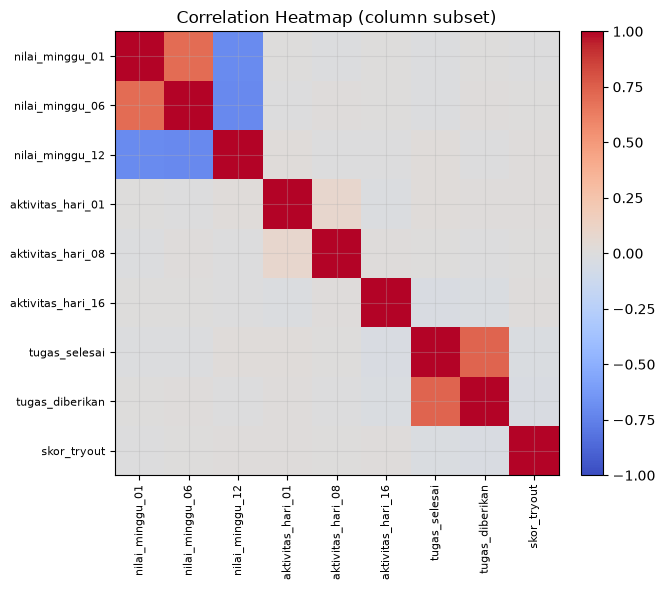

In [65]:
subset = (["nilai_minggu_01", "nilai_minggu_06", "nilai_minggu_12"] +

          ["aktivitas_hari_01", "aktivitas_hari_08", "aktivitas_hari_16"] +

          ["tugas_selesai", "tugas_diberikan", "skor_tryout"])

cmat = train[subset].corr()


fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cmat, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(subset))); ax.set_xticklabels(subset, rotation=90, fontsize=8)

ax.set_yticks(range(len(subset))); ax.set_yticklabels(subset, fontsize=8)

fig.colorbar(im, fraction=0.046, pad=0.04)

ax.set_title("Correlation Heatmap (column subset)")

plt.tight_layout(); plt.show() 

In [66]:
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline

from sklearn.model_selection import cross_val_score

y = train["target"]
X_raw = train[feat_cols]
def evaluate(features, target=y, cv=5):

    '''Mean CV accuracy, standardized Logistic Regression.'''

    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))

    return cross_val_score(model, features, target, cv=cv).mean()

baseline = evaluate(X_raw)

print(f"Baseline (raw columns, Logistic Regression): {baseline:.3f}") 

Baseline (raw columns, Logistic Regression): 0.353


In [67]:
from xgboost import XGBClassifier
xgb = XGBClassifier(tree_method="hist", n_estimators=400, max_depth=6,

                    learning_rate=0.1, random_state=0, n_jobs=-1,

                    eval_metric="mlogloss", verbosity=0)

xgb_raw = cross_val_score(xgb, X_raw, y, cv=3).mean()

print(f"XGBoost (raw columns): {xgb_raw:.3f}") 

XGBoost (raw columns): 0.442


In [68]:
week_cols = [f"nilai_minggu_{i:02d}" for i in range(1, 13)]
day_cols  = [f"aktivitas_hari_{i:02d}" for i in range(1, 17)]
fe = train[feat_cols].copy()

for name, cols in [("week", week_cols), ("day", day_cols)]:

    fe[f"{name}_mean"]  = train[cols].mean(axis=1)
    fe[f"{name}_std"]   = train[cols].std(axis=1)
    fe[f"{name}_max"]   = train[cols].max(axis=1)
    fe[f"{name}_min"]   = train[cols].min(axis=1)
    fe[f"{name}_range"] = train[cols].max(axis=1) - train[cols].min(axis=1)

added = [c for c in fe.columns if c not in feat_cols]
print("Added summary features:", added)
acc_agg = evaluate(fe)
print(f"\nRaw baseline           : {baseline:.3f}")
print(f"+ group aggregations   : {acc_agg:.3f}")



Added summary features: ['week_mean', 'week_std', 'week_max', 'week_min', 'week_range', 'day_mean', 'day_std', 'day_max', 'day_min', 'day_range']

Raw baseline           : 0.353
+ group aggregations   : 0.403


In [69]:
agg_corr = (fe[added]

            .apply(lambda col: abs(np.corrcoef(col, y)[0, 1]))
            .sort_values(ascending=False)) 

XGBoost raw columns     : 0.442
XGBoost + aggregations  : 0.452
week_std      0.396
week_range    0.375
week_max      0.338
week_min      0.325
day_range     0.050
day_max       0.044
day_std       0.039
day_min       0.027
week_mean     0.013
day_mean      0.013


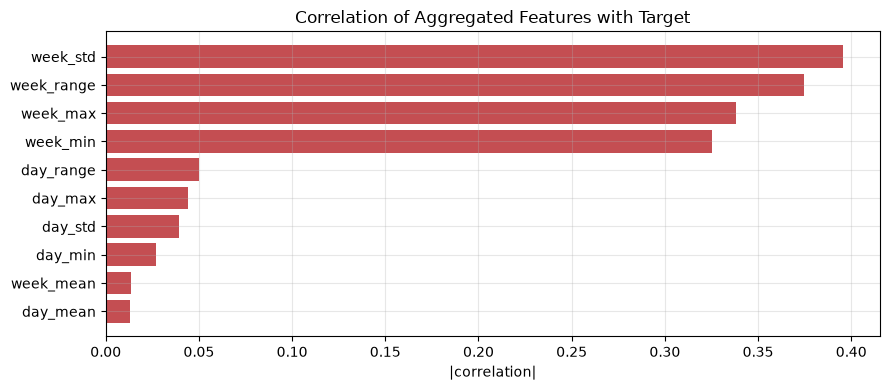

In [70]:
acc_agg_xgb = cross_val_score(xgb, fe, y, cv=3).mean()
print(f"XGBoost raw columns     : {xgb_raw:.3f}")
print(f"XGBoost + aggregations  : {acc_agg_xgb:.3f}")
print(agg_corr.round(3).to_string())

fig, ax = plt.subplots()
ax.barh(agg_corr.index[::-1], agg_corr.values[::-1], color="#C44E52")
ax.set_title("Correlation of Aggregated Features with Target")
ax.set_xlabel("|correlation|")
plt.tight_layout(); plt.show()

In [71]:
summary = pd.DataFrame([
    ("Linear - raw columns", baseline),
    ("Linear - + aggregations", acc_agg),
    ("XGBoost - raw columns", xgb_raw),
    ("XGBoost - + aggregations", acc_agg_xgb),
], columns=["pipeline", "cv_accuracy"])
print(summary.to_string(index=False)) 

                pipeline  cv_accuracy
    Linear - raw columns     0.353125
 Linear - + aggregations     0.403438
   XGBoost - raw columns     0.441873
XGBoost - + aggregations     0.451872


In [72]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    tree_method="hist", 
    n_estimators=500, 
    max_depth=5,
    learning_rate=0.03, 
    random_state=0, 
    n_jobs=-1,
    eval_metric="mlogloss"
)
xgb_model.fit(X_train_final, y)
print("Model XGBoost berhasil dilatih!")

Model XGBoost berhasil dilatih!


In [73]:
pred_final = xgb_model.predict(X_test_final)
submission_final = pd.DataFrame({
    "id": test["id"], 
    "target": pred_final
})
submission_final.to_csv("submission_final.csv", index=False)
print("submission_final.csv sukses disimpan!")
submission_final.head()

submission_final.csv sukses disimpan!


,id,target
0,3,2
1,12,2
2,14,3
3,18,3
4,28,0


In [74]:
def make_features_engineered(df):
    out = df[[c for c in df.columns if c not in ("id", "target")]].copy()
    wk = [f"nilai_minggu_{i:02d}" for i in range(1, 13)]
    dy = [f"aktivitas_hari_{i:02d}" for i in range(1, 17)]
    
    for name, cols in [("week", wk), ("day", dy)]:
        out[f"{name}_mean"]  = df[cols].mean(axis=1)
        out[f"{name}_std"]   = df[cols].std(axis=1)
        out[f"{name}_max"]   = df[cols].max(axis=1)
        out[f"{name}_min"]   = df[cols].min(axis=1)
        out[f"{name}_range"] = df[cols].max(axis=1) - df[cols].min(axis=1)
        
    out['tren_nilai_total'] = df['nilai_minggu_12'] - df['nilai_minggu_01']
    out['tren_nilai_akhir'] = df['nilai_minggu_12'] - df['nilai_minggu_08']
    out['rasio_tugas'] = df['tugas_selesai'] / (df['tugas_diberikan'] + 1e-5)
    out['total_beban_belajar'] = df['tugas_diberikan'] * out['day_mean']
    out['interaksi_kehadiran_motivasi'] = df['indeks_kehadiran'] * df['skor_motivasi']
    
    out['kehadiran_per_motivasi'] = df['indeks_kehadiran'] / (df['skor_motivasi'] + 1e-5)
    out['day_cv'] = out['day_std'] / (out['day_mean'] + 1e-5)
    out['tryout_per_beban'] = df['skor_tryout'] / (df['tugas_diberikan'] + 1e-5)
    
    return out
X_train_final = make_features_engineered(train)
X_test_final  = make_features_engineered(test)
print("Jumlah kolom setelah upgrade:", X_train_final.shape[1])

Jumlah kolom setelah upgrade: 59


In [75]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    tree_method="hist",
    n_estimators=1000,          
    max_depth=4,                
    learning_rate=0.015,        
    subsample=0.8,              
    colsample_bytree=0.8,       
    random_state=0,
    n_jobs=-1,
    eval_metric="mlogloss"
)
xgb_model.fit(X_train_final, y)
print("Model XGBoost Versi Upgrade Berhasil Dilatih!")

Model XGBoost Versi Upgrade Berhasil Dilatih!


In [76]:
pred_final = xgb_model.predict(X_test_final)
submission_final = pd.DataFrame({
    "id": test["id"], 
    "target": pred_final
})
submission_final.to_csv("submission_final.csv", index=False)
print("submission_final.csv sukses disimpan!")
submission_final.head()

submission_final.csv sukses disimpan!


,id,target
0,3,2
1,12,2
2,14,3
3,18,3
4,28,0


In [77]:
from sklearn.model_selection import cross_val_score
skor_baru = cross_val_score(xgb_model, X_train_final, y, cv=3).mean()
print(f"Akurasi Model Baru Setelah Upgrade: {skor_baru * 100:.2f}%")

Akurasi Model Baru Setelah Upgrade: 46.03%


In [78]:
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
cat_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.03,
    depth=5,
    random_seed=42,
    verbose=0 # Biar gak menuh-menuhin log
)

skor_cat = cross_val_score(cat_model, X_train_final, y, cv=3).mean()
print(f"Akurasi pake CatBoost: {skor_cat * 100:.2f}%")

Akurasi pake CatBoost: 51.31%


In [79]:
cat_model.fit(X_train_final, y)
pred_cat = cat_model.predict(X_test_final)
submission_cat = pd.DataFrame({
    "id": test["id"], 
    "target": pred_cat.flatten()
})
submission_cat.to_csv("submission_final.csv", index=False)
print("submission_final.csv BERHASIL DI-UPGRADE PAKE CATBOOST (51.31%)!")
submission_cat.head()

submission_final.csv BERHASIL DI-UPGRADE PAKE CATBOOST (51.31%)!


,id,target
0,3,2
1,12,2
2,14,3
3,18,3
4,28,0


In [80]:
xgb_model.fit(X_train_final, y)
proba_cat = cat_model.predict_proba(X_test_final)
proba_xgb = xgb_model.predict_proba(X_test_final)
proba_ensemble = (0.7 * proba_cat) + (0.3 * proba_xgb)
pred_ensemble = proba_ensemble.argmax(axis=1)
submission_ensemble = pd.DataFrame({
    "id": test["id"], 
    "target": pred_ensemble
})
submission_ensemble.to_csv("submission_final.csv", index=False)
print("Submission final hasil kolaborasi Ensemble sukses disimpan!")
submission_ensemble.head()

Submission final hasil kolaborasi Ensemble sukses disimpan!


,id,target
0,3,2
1,12,2
2,14,3
3,18,3
4,28,0


In [81]:
def make_features_ultra(df):
    out = df[[c for c in df.columns if c not in ("id", "target")]].copy()
    wk = [f"nilai_minggu_{i:02d}" for i in range(1, 13)]
    dy = [f"aktivitas_hari_{i:02d}" for i in range(1, 17)]
    
    for name, cols in [("week", wk), ("day", dy)]:
        out[f"{name}_mean"]  = df[cols].mean(axis=1)
        out[f"{name}_std"]   = df[cols].std(axis=1)
        out[f"{name}_max"]   = df[cols].max(axis=1)
        out[f"{name}_min"]   = df[cols].min(axis=1)
        out[f"{name}_range"] = df[cols].max(axis=1) - df[cols].min(axis=1)
        
    out['tren_nilai_total'] = df['nilai_minggu_12'] - df['nilai_minggu_01']
    out['tren_nilai_akhir'] = df['nilai_minggu_12'] - df['nilai_minggu_08']
    out['rasio_tugas'] = df['tugas_selesai'] / (df['tugas_diberikan'] + 1e-5)
    out['total_beban_belajar'] = df['tugas_diberikan'] * out['day_mean']
    out['interaksi_kehadiran_motivasi'] = df['indeks_kehadiran'] * df['skor_motivasi']
    
    out['kehadiran_per_motivasi'] = df['indeks_kehadiran'] / (df['skor_motivasi'] + 1e-5)
    out['day_cv'] = out['day_std'] / (out['day_mean'] + 1e-5)
    out['tryout_per_beban'] = df['skor_tryout'] / (df['tugas_diberikan'] + 1e-5)
    
    out['stabilitas_nilai'] = out['week_std'] / (out['week_mean'] + 1e-5)
    out['rasio_literasi_tryout'] = df['skor_literasi'] / (df['skor_tryout'] + 1e-5)
    out['total_skor_kognitif'] = df['skor_tryout'] + df['skor_literasi'] + df['skor_minat_belajar']
    
    return out

X_train_ultra = make_features_ultra(train)
X_test_ultra  = make_features_ultra(test)

cat_ultra = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.015,
    depth=6,
    l2_leaf_reg=7,
    bagging_temperature=0.8,
    random_seed=42,
    verbose=0
)

skor_ultra = cross_val_score(cat_ultra, X_train_ultra, y, cv=3).mean()
print(f"Akurasi Ultra Improve: {skor_ultra * 100:.2f}%")

Akurasi Ultra Improve: 52.16%


In [82]:
cat_ultra.fit(X_train_ultra, y)
pred_ultra = cat_ultra.predict(X_test_ultra)

submission_ultra = pd.DataFrame({
    "id": test["id"], 
    "target": pred_ultra.flatten()
})

submission_ultra.to_csv("submission_final.csv", index=False)
print("submission_final.csv BERHASIL DI-UPGRADE MAKSIMAL!")
submission_ultra.head()

submission_final.csv BERHASIL DI-UPGRADE MAKSIMAL!


,id,target
0,3,1
1,12,2
2,14,3
3,18,3
4,28,0


In [83]:
print("Kolom yang ada di data kamu:")
print(train.columns.tolist())

Kolom yang ada di data kamu:
['id', 'nilai_minggu_01', 'nilai_minggu_02', 'nilai_minggu_03', 'nilai_minggu_04', 'nilai_minggu_05', 'nilai_minggu_06', 'nilai_minggu_07', 'nilai_minggu_08', 'nilai_minggu_09', 'nilai_minggu_10', 'nilai_minggu_11', 'nilai_minggu_12', 'skor_motivasi', 'skor_kedisiplinan', 'aktivitas_hari_01', 'aktivitas_hari_02', 'aktivitas_hari_03', 'aktivitas_hari_04', 'aktivitas_hari_05', 'aktivitas_hari_06', 'aktivitas_hari_07', 'aktivitas_hari_08', 'aktivitas_hari_09', 'aktivitas_hari_10', 'aktivitas_hari_11', 'aktivitas_hari_12', 'aktivitas_hari_13', 'aktivitas_hari_14', 'aktivitas_hari_15', 'aktivitas_hari_16', 'tugas_selesai', 'tugas_diberikan', 'kelas', 'urutan_ujian', 'skor_tryout', 'jarak_rumah_km', 'skor_ekstrakurikuler', 'indeks_kehadiran', 'skor_literasi', 'jumlah_saudara', 'skor_minat_belajar', 'target']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

def make_features_target_80(df):
    df = df.copy()
  
    kolom_mingguan = sorted([c for c in df.columns if 'nilai_minggu_' in c])
    kolom_harian = sorted([c for c in df.columns if 'aktivitas_hari_' in c])
    df['mean_nilai'] = df[kolom_mingguan].mean(axis=1)
    df['std_nilai'] = df[kolom_mingguan].std(axis=1)
    df['max_nilai'] = df[kolom_mingguan].max(axis=1)
    df['min_nilai'] = df[kolom_mingguan].min(axis=1)
    df['mean_aktivitas'] = df[kolom_harian].mean(axis=1)
    df['std_aktivitas'] = df[kolom_harian].std(axis=1)
    df['tren_nilai_total'] = df[kolom_mingguan[-1]] - df[kolom_mingguan[0]]
    df['tren_nilai_akhir'] = df[kolom_mingguan[-1]] - df[kolom_mingguan[-3]] # 3 minggu terakhir
    df['momentum_nilai'] = df[kolom_mingguan[6:]].mean(axis=1) - df[kolom_mingguan[:6]].mean(axis=1)
    df['stabilitas_belajar'] = df['std_aktivitas'] / (df['mean_aktivitas'] + 1)
    df['rasio_tugas'] = df['tugas_selesai'] / (df['tugas_diberikan'] + 1)
    df['total_skor_dasar'] = df['skor_tryout'] + df['skor_literasi'] + df['skor_minat_belajar']
    df['indeks_keaktifan'] = df['skor_motivasi'] * (df['indeks_kehadiran'] + 1)

    if 'jarak_rumah_km' in df.columns:
        df['jarak_rumah_clean'] = df['jarak_rumah_km'].clip(lower=0)
        df['log_jarak_rumah'] = np.log1p(df['jarak_rumah_clean'])
    if 'kelas' in df.columns:
        df['avg_tryout_kelas'] = df.groupby('kelas')['skor_tryout'].transform('mean')
        # Selisih skor siswa dibanding rata-rata temannya di kelas
        df['deviasi_tryout_kelas'] = df['skor_tryout'] - df['avg_tryout_kelas']
        df['avg_tugas_kelas'] = df.groupby('kelas')['tugas_selesai'].transform('mean')
        df['deviasi_tugas_kelas'] = df['tugas_selesai'] - df['avg_tugas_kelas']
        
    return df

# Load Dataset 
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

df_train = make_features_target_80(train)
df_test = make_features_target_80(test)
drop_cols = ['id', 'target', 'jarak_rumah_km'] if 'jarak_rumah_km' in df_train.columns else ['id', 'target']
X = df_train.drop(columns=drop_cols, errors='ignore')
y = df_train['target']
X_test = df_test.drop(columns=['id', 'jarak_rumah_km'], errors='ignore')
cat_features_indices = [X.columns.get_loc('kelas')] if 'kelas' in X.columns else []

# 5-Fold Cross Validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(df_train))
test_predictions = np.zeros((len(df_test), 4))

print("=== IMPROVE ===")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(
        iterations=3000,          
        learning_rate=0.025,       
        depth=6,                  
        l2_leaf_reg=5,            
        loss_function='MultiClass',
        random_seed=42,
        verbose=0
    )
    
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100, 
        cat_features=cat_features_indices
    )
    val_preds = model.predict(X_val).flatten()
    oof_predictions[val_idx] = val_preds
    
    test_predictions += model.predict_proba(X_test) / n_splits
    fold_acc = accuracy_score(y_val, val_preds)
    print(f"Fold {fold+1} Akurasi Validasi: {fold_acc:.4f}")

final_local_acc = accuracy_score(y, oof_predictions)
print(f"\n>>> [ESTIMASI AKURASI TOTAL]: {final_local_acc:.4f}")
submission_80 = pd.DataFrame({
    'id': df_test['id'],
    'target': np.argmax(test_predictions, axis=1)
})
submission_80.to_csv('submission_target_80.csv', index=False)
print("\nIMPROVE BERHASIL!")

=== IMPROVE ===
Fold 1 Akurasi Validasi: 0.5312
